# Programming exercise 10: Ground State Search with the Variational Monte Carlo Method

Due on Monday, 29.06.2026, 20h


In [2]:

import flax.linen as nn

import jax
import jax.numpy as jnp

import os

import scipy.sparse as sparse 
import scipy.sparse.linalg as sLA

import matplotlib.pyplot as plt

import Comp_Quant_Dynam as cqd

# JAX wants to work on GPUs by default, 
# which we have to explicitly bypass if no GPUs are available on the device
os.environ["JAX_PLATFORM_NAME"] = "cpu"

We will again be looking at the transverse field Ising model (TFIM) in 1D from exercise sheet 8,
$$
H=\sum_{i=0}^{N-1} -J\sigma_z^{(i)}\sigma_z^{(i+1)} - B \sigma_x^{(i)}.
$$
In this sheet we will construct two different variational ansatzes: a Jastrow ansatz and a Feed-Forward Neural Network ansatz in order to do a ground state search by minimizing the variational energy,

$$E_\text{var}(\mathbf{\theta}) = \frac{\braket{\psi_\mathbf{\theta}|H|\psi_\mathbf{\theta}}}{\braket{\psi_\mathbf{\theta}|\psi_\mathbf{\theta}}} \geq E_\text{gs}.$$

Thus, the ansatzes will represent the variational wave function $\braket{\mathbf{s}|\psi_\mathbf{\theta}}=\psi_{\mathbf{\theta}}(\mathbf{s})$ and we will optimize the variational parameters $\mathbf{\theta}$, such that after convergence $\ket{\psi_\mathbf{\theta}}$ corresponds to the ground state of the TFIM Hamiltonian. We will use our results from sheet 8 to benchmark the convergence of our algorithm.

We will be using some libraries that are state-of-the-art for optimization tasks with neural networks such as `jax` (https://docs.jax.dev/en/latest/index.html), `flax` (https://flax-linen.readthedocs.io/en/latest/#) and `optax` (https://optax.readthedocs.io/en/latest/). 

### Brief introduction to the libraries: `jax`, `flax` and `optax`

`jax` is a "[...] library for array-oriented numerical computation (à la NumPy), with automatic differentiation and JIT compilation to enable high-performance machine learning research" developed by Google. `flax` is the `jax`-based library for constructing artificial neural networks and `optax` is the `jax`-based library of optimizers for training neural networks, all in a (possibly GPU) accelerated way.


In addition to auto-diff and JIT compilation via Open XLA, JAX functions can be automatically vectorized and are compatible with fast parallel execution on GPUs. All NumPy functions that you will need are copied from NumPy and optimized by JAX under the package `jax.numpy`.

In [3]:
# One can define arrays in the same way as with numpy
sx = jnp.array([[0,1],[1,0]])/2

# and use matrix operations
sx2 = jnp.dot(sx, sx)
matexp = jnp.exp(sx2)

print(matexp)

[[1.2840254 1.       ]
 [1.        1.2840254]]


For variational (Monte Carlo) optimization tasks, one usually needs to use random sampling with the help of pseudo-random-number generator (PRNG) keys. Every key takes a seed such that the result is pseudo-random yet reproducible. JAX has many tools developed in `jax.random` precisely for this purpose.

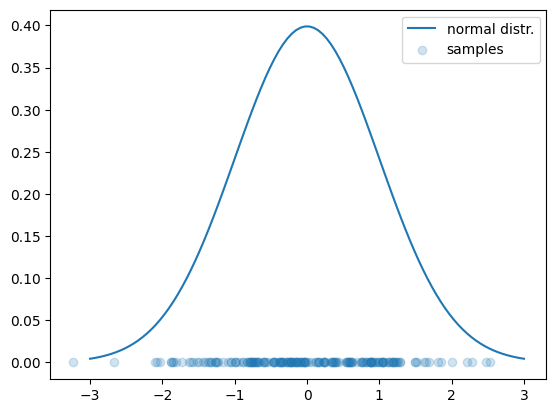

In [4]:
seed = 2 # Choose a random seed 
key = jax.random.PRNGKey(seed) # Define a PRNG key to use 

num_samples = 200

x_samples = jax.random.normal(key, shape=(num_samples,)) # Sample from a normal distribution

def normal(x):
    return jnp.sqrt(1/(2 * jnp.pi)) * jnp.exp(-x**2/2)
x = jnp.linspace(-3, 3, 100)

plt.plot(x, normal(x), label="normal distr.")
plt.scatter(x_samples, jnp.zeros_like(x_samples), label="samples", alpha=0.2)
plt.legend()

One side-effect of JAX' XLA optimzed code is that one has to avoid using regular `if`, `for` and `while` loops for accelerated computing on GPUs, since these can make the otherwise highly optimized code either crash or largely slow down. Here, we will be running code firstly on our local computer, thus you can use regular loop structures. But for making use of the GPU acelaration, one uses the `jax`-internal alternatives from `jax.lax`. For example a for-loop can be written using `jax.lax.scan`

In [5]:
def step_function(carry, x):
    next_carry = carry + x
    return next_carry, next_carry


numbers = jnp.array([1, 2, 3, 4, 5])
initial_sum = 0

final_sum, running_sums = jax.lax.scan(step_function, initial_sum, numbers)

print("Final state:", final_sum)
print("History of states:", running_sums)

Final state: 15
History of states: [ 1  3  6 10 15]


### Defining variational models via `flax`
Using `flax.linen` we can create neural networks or other variational ansatzes in a simple class definition. 

In [6]:

class myModel(nn.Module):
        
        # We define our class as an `nn.Module` so that it inherits the flax.linen structure

        """  """

        out_dim: int = 1
        actfunc: callable = nn.tanh # Choose a suitable activation function

        @nn.compact
        def __call__(self, x):     

            # Here we define how inputs x are called and passed through the network
            
            out = self.actfunc(nn.Dense(self.out_dim, kernel_init=jax.nn.initializers.normal(),
                          bias_init=jax.nn.initializers.zeros)(x))   # We initialize the w
            

            return out[..., 0]
        


# Initialize the class
mymodel = myModel(out_dim=1, actfunc=nn.tanh)


dummy_input = jnp.ones((1, 10))
key = jax.random.PRNGKey(2)        

# Initialize the model with random parameters using a dummy input        
params = mymodel.init(key, dummy_input)

# Notice that the parameters of a flax module are stored as a dictionary NOT an array
print("Data type of the flax params:", type(params))

# We can take a closer look at the params structure 
print("Initialized Parameters Structure:",jax.tree_util.tree_map(lambda x: x.shape, params))

# If one wishes one can ravel the parameters dictionary into an array 
params_flat, unravel_func = jax.flatten_util.ravel_pytree(params)
print("Model parameters as a flattened array:", params_flat)

# The unravel function then knows how to wrap the aray back into the right dictionary form
# In order to apply the parameters, they have to be in the dictionary form
params =  unravel_func(params_flat)

# We can compute outputs of our model by applying the model onto inputs
output = mymodel.apply(params, dummy_input)
print(rf"Output of the randomly initialized model: {output}") 

Data type of the flax params: <class 'dict'>
Initialized Parameters Structure: {'params': {'Dense_0': {'bias': (1,), 'kernel': (10, 1)}}}
Model parameters as a flattened array: [ 0.          0.00648656  0.00845536  0.00376873  0.01555608  0.001989
  0.00457466  0.00686578  0.00126043  0.01455669 -0.01028854]
Output of the randomly initialized model: [0.05317456]


### Exercise 1: The Jastrow Ansatz and Markov Chain Monte Carlo (MCMC)

We will start by constructing a short-range Jastrow ansatz that entangles nearest and next-to-nearest neighbours,

$$\braket{\mathbf{s}|\psi_\text{jas}} = \exp\left(\sum\limits_{i}J_1 \sigma^z_i\sigma^z_{i+1} + J_2 \sigma^z_i\sigma^z_{i+2}\right),$$

where the parameters $J_1$ and $J_2$ have to be learned. We will construct the Jastrow ansatz using a `flax`-based class. It is common to define the logarithm of the variational wave functions, so we define `Jastrow()`$=\log \psi_\text{jas}$

- After defining the Jastrow ansatz, initialize the model and test the output on a spin state $\ket{111...111}$ with $N=10$. 

In order to do ground state search via variational Monte Carlo, we need a sampling algorithm that can generate random vectors of $N$ spins. But not all spin configurations are equally likely! That's why we use Markov Chain Monte Carlo (MCMC) to sample from the Born distribution of the variational wave function $p_{\mathbf{\theta}}(\mathbf{s}) = \frac{|{\psi_{\mathbf{\theta}}(\mathbf{s})}|^2}{\braket{\psi_{\mathbf{\theta}}|\psi_{\mathbf{\theta}}}}$. 

For this, we have implemented a sampler via the Metropolis-Hastings algorithm using `jax.lax.scan`. Make sure you understand how the sampler works. Compare the code to the algorithm sketch below: At each step
- Start with configuration s
- Propose a new spin state s' by doing a random spin flip (0 -> 1 or 1 -> 0)
- Accept the proposed new spin state with acceptance probability

$$p_\text{accept}(s,s') = \min \left( 1 , \frac{p_{\mathbf{\theta}}(\mathbf{s'})}{p_{\mathbf{\theta}}(\mathbf{s})}\right)$$
- Otherwise keep s
- Repeat until $N_\text{samp}$ samples have been accepted.

Why is there a nested "full sweep" loop within the outer loop? Why is this important? Think about the independence and autocorrelations of samples.

- Since we are using single spin flips, it is necessary to roughly do a full sweep over all spins, to make sure that two samples that are accepted after one another are much less likely to be autocorrelated. This is especially important when we want to sample systems with a larger spin number.

In [7]:
# Initialize the Jastrow model with a PRNG key and a dummy input
logjas = cqd.utility.Jastrow()

N_spins = 20

key = jax.random.PRNGKey(0)
dummy_x = jnp.ones(shape=(1, N_spins))
jastrow_params = logjas.init(key, dummy_x)

# Obtain outputs of the model by applying the model onto inputs

output = logjas.apply(jastrow_params, dummy_x)

print(r"Output of the Jastrow ansatz with random parameters on spin $\ket{111..11}$ state:", jnp.exp(jnp.asarray(output)))        

Output of the Jastrow ansatz with random parameters on spin $\ket{111..11}$ state: [1.1452005]


In [8]:
num_samples = 15

spin_samples = cqd.utility.MCMC_Sampler_Metropolis_Hastings(model=logjas,
                                                            params=jastrow_params, 
                                                            init_state = jnp.ones((N_spins,)), 
                                                            num_samples=num_samples, 
                                                            PRNGkey= jax.random.PRNGKey(7) )

print(f"Let us look at {num_samples} spin state samples:")
print(" ")
print(spin_samples)

Let us look at 15 spin state samples:
 
[[1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0.]
 [0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1.]
 [0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.]
 [0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0.]
 [0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1.]
 [0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1.]
 [1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0.]
 [1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1.]
 [1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0.]
 [1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1.]
 [0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1.]
 [0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1.]]


### Exercise 2: Ground State Search via Stochastic Gradient Descent (SGD) 

Before we define our ground state search algorithm, let us define our minimization objective, the variational energy expectation value $E_\text{var}(\mathbf{\theta})$ which is given by,

$$
E_\text{var}(\mathbf{\theta}) =  \sum\limits_{s} \frac{|\psi_{\mathbf{\theta}}(s)|^2}{\braket{\psi_{\mathbf{\theta}}|\psi_{\mathbf{\theta}}}} E_\text{loc} (s) = \langle E_\text{loc} (s)\rangle_{s\sim p_{\mathbf{\theta}}},
$$
here $E_\text{loc} (s)$ is the local estimate of the energy that can be further written down as

$$
E_\text{loc} (s) = \frac{\bra{s}\hat{H}\ket{\psi_{\mathbf{\theta}}}}{\braket{s|\psi_{\mathbf{\theta}}}} = \sum\limits_{s'} \bra{s}\hat{H}\ket{s'} \frac{\psi_{\mathbf{\theta}}(s')}{\psi_{\mathbf{\theta}}(s)}.
$$

Now, we can implement the gradient of the variational energy $E_\text{var}(\mathbf{\theta})$ as the Monte Carlo averaged expression,

$$\nabla_{\theta_k}E_\text{var}(\mathbf{\theta}) = 2 \, \text{Re} \left[ \langle O^*_k(s) E_\text{loc} (s)\rangle_{s\sim p_{\mathbf{\theta}}} - \langle O^*_k(s)\rangle_{s\sim p_{\mathbf{\theta}}} \langle E_\text{loc} (s)\rangle_{s\sim p_{\mathbf{\theta}}} \right],$$

with the logarithmic variational derivatives $O_k (s) = \partial_{\theta_k} \log \psi_{\mathbf{\theta}}(s)$ and update the variational parameters accordingly via gradient descent,

$$\theta^{(i+1)} = \theta^{(i)} - \eta \nabla_{\theta_k}E_\text{var}(\mathbf{\theta}), $$

using the optax optimizer `optax.adam(learning_rate=lr)` or  `optax.adabelief(learning_rate=lr)` and the update functions `optimizer.update()` as well as `optax.apply_updates()`.

- Plot the variational ground state energy $E_\text{gs}(\mathbf{\theta})$ against the number of iterations and show its convergence by comparing to the exact ground state energy
- (Optional): Play around with different learning rates $\eta_i$ and number of MC samples $N_\text{MC}$ to see the effect on the speed of convergence and statistical fluctuations

Ground state energy truth: -20.452590298421462
Iteration    0 | Variational Energy: -6.207212
Iteration   50 | Variational Energy: -8.493682
Iteration  100 | Variational Energy: -19.081715
Iteration  150 | Variational Energy: -20.127020
Iteration  200 | Variational Energy: -20.379688
Iteration  250 | Variational Energy: -20.405020
Iteration  300 | Variational Energy: -20.401018
Iteration  350 | Variational Energy: -20.422173
Iteration  399 | Variational Energy: -20.446602


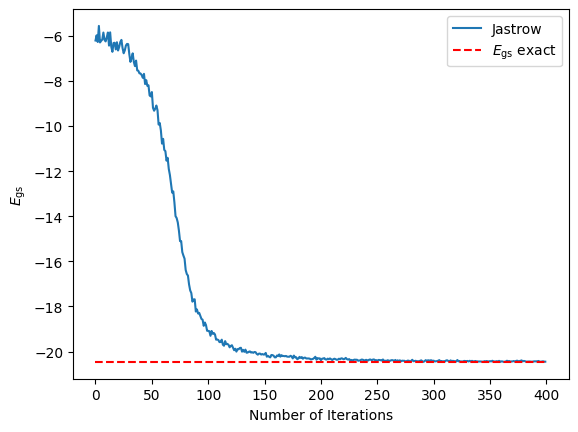

In [9]:
B = 0.3

# Get the analytical ground state energy
Egs_truth = cqd.hamiltonians.E_TFIM_individual_exact(N_spins, B)
print("Ground state energy truth:", Egs_truth)

# Perform the ground state search
params_last_jastrow , energy_history_jastrow = cqd.utility.perform_gs_search(model=logjas,
                                                        N_spins=N_spins,
                                                        init_params=jastrow_params,
                                                        B=B, 
                                                        num_iters=400, 
                                                        N_MC=500, lr=1e-3,
                                                        key=jax.random.PRNGKey(22))


plt.plot(energy_history_jastrow, label="Jastrow")
plt.hlines(Egs_truth, xmin=0, xmax=len(energy_history_jastrow), linestyles="--", label=r"$E_\text{gs}$ exact", color="r")
plt.xlabel("Number of Iterations")
plt.ylabel(r"$E_\text{gs}$")

plt.legend()

- We observe that the Jastrow ansatz is capable of learning the ground state energy quickly. This has to do with two facts: It is a fairly simple model with parameters $J_1$ and $J_2$ and the construction of the Jastrow model already entails approximate physical prior knowledge about the spin system and its correlations. This will not be the case for a simple feed-forward neural network. 
- The number of used Monte Carlo samples especially affects the stochastic fluctuations of the variational energy $E_\text{var}$ since the variance scales with $1/\sqrt{N_\text{MC}}$. When we use more samples, the SGD algorithm also fluctuates less. 
- With larger learning rates, the algorithm takes much larger steps on the optimization landscape, which can accelerate the optimization, yet if the model is not stable enough, this can lead to a sudden jump out of the minimum.

### Exercise 3: Ground State Search via Neural Quantum States

Now we can build the Neural Quantum States (NQS) ansatz (https://www.science.org/doi/10.1126/science.aag2302). Construct a feed-forward neural network (FFNN), with randomly initialized network parameters. For spin systems usually, the FFNN takes a vector of spins $\mathbf{\sigma}$ as inputs and returns the logarithm of the spin wave function as an output, 

$$\log\psi_{\mathbf{\theta}}(\mathbf{\sigma}) = \frac{1}{2}\log \rho_{\mathbf{\theta}}(\mathbf{\sigma}) + i \phi_{\mathbf{\theta}}(\mathbf{\sigma}).$$

But here the ground state wave function of the 1D TFIM is purely real, so we can construct a FFNN model that outputs a single real number.

Choose a suitable nonlinear activation function, and initialize the FFNN with random variational parameters $\mathbf{\theta}$ chosen from a normal distribution. The $l$-th layer of the Feed-Forward Neural Network consists of the weight matrix $W^{(l)}_{kl}$ and bias vector $b^{(l)}_l$ and the output is sent through a nonlinear activation function,

$$\text{FFNN}^{(l+1)}(\mathbf{s}) = \text{ActFunc}\left( \sum\limits_{k}W^{(l)}_{kl}s^{(l)}_k + b^{(l)}_l\right).$$

Initialize the weights $W^{(l)}_{kl}$ from a normal distribution and the biases $b^{(l)}_l$ from zero. `jax.nn.initializers.lecun_normal` and `jax.nn.initializers.zeros` functions may be helpful.

- Run the ground state search algorithm now for the NQS ansatz and compare the convergence in a plot with the Jastrow ansatz using again the analytical ground state energy benchmark.
- How does the NQS ansatz perform for large and small network sizes and larger and smaller learning rates? What are potential reasons for this performance and possible ways to improve?

(Optional): In order to get an intuition of how the structure of the FFNN changes its performance you can play around with different hidden layer numbers and activation functions on https://playground.tensorflow.org, especially for regression problems.

In [10]:
# Initialize the FFNN class
logpsi_FFNN = cqd.utility.FFNN(features=(2 * N_spins, 2 * N_spins, N_spins), out_dim=1, actfunc=nn.tanh)

dummy_input = jnp.ones((1, N_spins)) # Push through a dummy input to initialize the parameters
print(dummy_input.shape)
key = jax.random.PRNGKey(2)        
        
FFNN_params = logpsi_FFNN.init(key, dummy_input)

print("Initialized Parameters Structure:")
print(jax.tree_util.tree_map(lambda x: x.shape, FFNN_params))

log_psi = logpsi_FFNN.apply(FFNN_params, dummy_input)
print(rf"Log-wavefunction output $\log \psi_\theta (\sigma)$: {log_psi}") 
       

(1, 20)
Initialized Parameters Structure:
{'params': {'Dense_0': {'bias': (40,), 'kernel': (20, 40)}, 'Dense_1': {'bias': (40,), 'kernel': (40, 40)}, 'Dense_2': {'bias': (20,), 'kernel': (40, 20)}, 'Dense_3': {'bias': (1,), 'kernel': (20, 1)}}}
Log-wavefunction output $\log \psi_\theta (\sigma)$: [-0.3525523]


Ground state energy truth: -20.452590298421462
Iteration    0 | Variational Energy: -5.419342
Iteration   50 | Variational Energy: -13.068242
Iteration  100 | Variational Energy: -17.165831
Iteration  150 | Variational Energy: -17.266289
Iteration  200 | Variational Energy: -17.053411
Iteration  250 | Variational Energy: -17.091408
Iteration  300 | Variational Energy: -17.078831
Iteration  350 | Variational Energy: -17.196747
Iteration  400 | Variational Energy: -17.239002
Iteration  450 | Variational Energy: -17.182217
Iteration  500 | Variational Energy: -17.324175
Iteration  550 | Variational Energy: -17.283792
Iteration  600 | Variational Energy: -17.265625
Iteration  650 | Variational Energy: -17.362997
Iteration  700 | Variational Energy: -17.267012
Iteration  750 | Variational Energy: -17.261660
Iteration  800 | Variational Energy: -17.413576
Iteration  850 | Variational Energy: -17.355663
Iteration  900 | Variational Energy: -17.366060
Iteration  950 | Variational Energy: -17.4

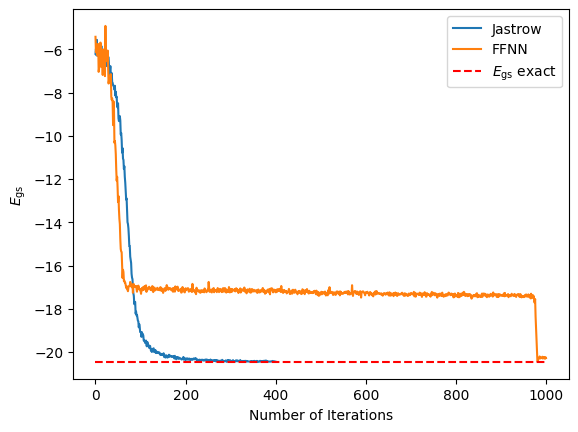

In [11]:
B = 0.3
# Get the analytical ground state energy
Egs_truth = cqd.hamiltonians.E_TFIM_individual_exact(N_spins, B)
print("Ground state energy truth:", Egs_truth)

# Perform the ground state search
params_last_FFNN , energy_history_FFNN = cqd.utility.perform_gs_search(model=logpsi_FFNN,
                                                        init_params=FFNN_params,
                                                        N_spins=N_spins,
                                                        B=B, 
                                                        num_iters=1000, 
                                                        N_MC=100, lr=1e-3,
                                                        key=jax.random.PRNGKey(45))


plt.plot(energy_history_jastrow, label="Jastrow")
plt.plot(energy_history_FFNN, label="FFNN")
plt.hlines(Egs_truth, xmin=0, xmax=len(energy_history_FFNN), linestyles="--", label=r"$E_\text{gs}$ exact", color="r")
plt.xlabel("Number of Iterations")
plt.ylabel(r"$E_\text{gs}$")
plt.legend()

- We observe that the FFNN needs many more iterations to converge, which has to do with the fact that it has many more variational parameters to be fixed and has no prior knowledge about the ongoing physics. This makes the ansatz very expressive, which makes the FFNN applicable in regimes where the Jastrow ansatz is too approximative, yet the optimization takes longer. 
- Also notice the plateau in the middle and the sudden convergence that comes at later iterations. This is a very common optimization graph for artificial neural networks. Thus, one has to be careful about false convergences.

### Exercise 4: The ground state search of the tilted TFIM

In this exercise we look at the tilted 1D TFIM,

$$
H=\sum_{i=0}^{N-1} -J\sigma_z^{(i)}\sigma_z^{(i+1)} - B \sigma_x^{(i)} - g \sigma_z^{(i)}.
$$

where we add a longitudinal field $g$ to the system which breaks the spin-flip symmetry. Thus, for this system there exists no analytical solution of the ground state energy and exact diagonalization is only possible to a certain number of spins. Here comes the advantage of variational methods truly into play. Define the Hamiltonian from above analogously to sheet 8 and solve the ground state energy using exact diagonalization roughly for spin numbers $N\in \{2,\dots, 20\}$ and find the same ground state via variational Monte Carlo with your model of choice. Then push the limits of what is possible with ED by using the variational model for finding the ground state energies for larger systems $N\in \{21,\dots, 100\}$, as long as your computer can handle it.


Iteration    0 | Variational Energy: -2.460533
Iteration  100 | Variational Energy: -8.967193
Iteration  200 | Variational Energy: -12.112317
Iteration  300 | Variational Energy: -12.131077
Iteration  399 | Variational Energy: -12.133588
Iteration    0 | Variational Energy: -5.587848
Iteration  100 | Variational Energy: -19.841932
Iteration  200 | Variational Energy: -24.274899
Iteration  300 | Variational Energy: -24.316425
Iteration  399 | Variational Energy: -24.313189
Iteration    0 | Variational Energy: -7.040261


JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory allocating 6180868 bytes.

Error in callback <function _draw_all_if_interactive at 0x00000250FF1A0930> (for post_execute), with arguments args (),kwargs {}:


MemoryError: bad allocation

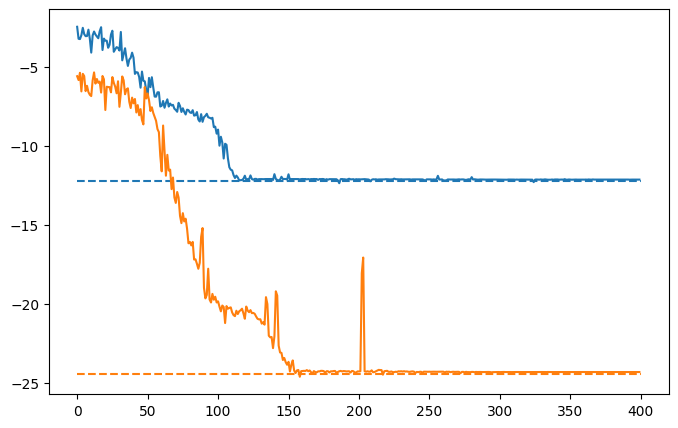

In [12]:
Ns = [10, 20, 25] # Iterate over the system sizes
B = 0.3
g = 0.2

plt.figure(figsize=(8, 5))
colors = plt.get_cmap('tab10')(range(10))

for idx, N in enumerate(Ns):
    color = colors[idx % len(colors)]

    logpsi_FFNN = cqd.utility.FFNN(features=(2 * N, 2 * N, N), out_dim=1, actfunc=nn.tanh)

    dummy_input = jnp.ones((1, N))
    key = jax.random.PRNGKey(idx + 2)        
            
    FFNN_params = logpsi_FFNN.init(key, dummy_input)

    if N < 22:
        # ED Solution
        Hmat = cqd.hamiltonians.build_H_tilted_TFIM_individual(N, B, g)
        evals, evecs = sLA.eigsh(Hmat, k=1, which='SA')
        
        # VMC ground state search
        _, energy_history_FFNN = cqd.utility.perform_gs_search_tilted(
            model=logpsi_FFNN, N_spins=N, init_params=FFNN_params,
            B=B, g=g, num_iters=400, N_MC=50, lr=1e-3, key=jax.random.PRNGKey(idx + 12)
        )
        
        plt.plot(energy_history_FFNN, label=rf"FFNN N={N}", color=color)
        plt.hlines(evals[0], xmin=0, xmax=len(energy_history_FFNN), 
                   linestyles="--", label=rf"$E_\text{{gs}}$ ED for N={N}", color=color)
    else:
        params_last_FFNN, energy_history_FFNN = cqd.utility.perform_gs_search_tilted(
            model=logpsi_FFNN, N_spins=N, init_params=FFNN_params,
            B=B, g=g, num_iters=700, N_MC=150, lr=1e-3, key=jax.random.PRNGKey(idx + 22)
        )
        
        plt.plot(energy_history_FFNN, label=rf"FFNN N={N}", color=color)

plt.xlabel("Number of Iterations")
plt.ylabel(r"$E_\text{gs}$")
plt.title(f"Ground states of the tilted TFIM with B={B}, g={g}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()


- This plot shows us the great use of variational ansatzes for many-body quantum physics, where numerically exact simulations (e.g. via ED) that become intractable for large system sizes due to the curse of dimensionality can be further pushed by using variational models such as neural quantum states. 
- Yet since for very large systems there potentially exists no ground truth, one has to extrapolate. 

### (Optional) Exercise 5: Testing the GPU Acceleration

Now, we want to test the true GPU acceleration that working with `jax` provides us. Therefore, go to Google Collab (https://colab.research.google.com), where you can upload this python notebook. Go to the upper right corner ("Connect") and choose to connect with device: T4 GPU. You need to first install the CQD package locally on to the cluster via:

`!pip install git+https://github.com/NiklasEuler/CQD_SS26.git `

Now, make sure that the line `os.environ["JAX_PLATFORM_NAME"] = "cpu"` is commented out and `jax` should automatically communicate with the GPU device, which is referred to as `CUDA device`.

- Make sure that both the MCMC sampler and the ground state search functions are defined purely with `jax.lax` loops such as `jax.lax.scan` or `jax.lax.fori_loop` and that trivially parallelizable batch evaluations are vectorized via `jax.vmap`. And enforce `JIT` compilation by using `@jax.jit` in front of your loss function.
- Run the ground state search from above on the GPUs and compare the runtime difference. 
- Now that the code runs faster, you might want to do a ground state search for even higher number of spins. 

In [3]:
# Test how many GPU devices are visible and run the code iff a CUDA device (GPU) or TPU is avaliable
if any((device.platform == 'gpu' or device.platform == 'tpu') for device in jax.devices()):
    print("Available devices:", jax.devices())

    Ns = [20, 25, 30, 50] # Iterate over different system sizes, now we can even go to longer chains
    B = 0.3 
    g = 0.2

    num_iters = 400 # Number of iterations
    num_MC_samples = 50 # Number of MC samples
    learning_rate = 1e-3 

    plt.figure(figsize=(8, 5))
    colors = plt.get_cmap('tab10')(range(10))

    for idx, N in enumerate(Ns):
        color = colors[idx % len(colors)]

        logpsi_FFNN = cqd.utility.FFNN(features=(2 * N, 2 * N, N), out_dim=1, actfunc=nn.tanh)

        dummy_input = jnp.ones((1, N))
        key = jax.random.PRNGKey(idx + 2)        
                
        FFNN_params = logpsi_FFNN.init(key, dummy_input)

        if N < 22:
            # ED Solution
            Hmat = cqd.hamiltonians.build_H_tilted_TFIM_individual(N, B, g)
            evals, evecs = sLA.eigsh(Hmat, k=1, which='SA')
            
            # VMC ground state search
            _, energy_history_FFNN = cqd.utility.perform_gs_search_tilted_GPU_accelerated(
                model=logpsi_FFNN, N_spins=N, init_params=FFNN_params,
                B=B, g=g, num_iters=num_iters, N_MC=num_MC_samples, lr=learning_rate, key=jax.random.PRNGKey(idx + 12)
            )
            
            plt.plot(energy_history_FFNN, label=rf"FFNN N={N}", color=color)
            plt.hlines(evals[0], xmin=0, xmax=len(energy_history_FFNN), 
                    linestyles="--", label=rf"$E_\text{{gs}}$ ED for N={N}", color=color)
        else:
            params_last_FFNN, energy_history_FFNN = cqd.utility.perform_gs_search_tilted_GPU_accelerated(
                model=logpsi_FFNN, N_spins=N, init_params=FFNN_params,
                B=B, g=g, num_iters=num_iters, N_MC=num_MC_samples, lr=learning_rate, key=jax.random.PRNGKey(idx + 22)
            )
            
            plt.plot(energy_history_FFNN, label=rf"FFNN N={N}", color=color)

    plt.xlabel("Number of Iterations")
    plt.ylabel(r"$E_\text{gs}$")
    plt.title(f"Ground states of the tilted TFIM with B={B}, g={g}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.tight_layout()
    plt.show()
else: 
    print("No CUDA device has been found!, I do not want to burn your laptop.")    

No CUDA device has been found!, I do not want to burn your laptop.
